In [39]:
# import libraries

# 1. to handle the data
import pandas as pd
import numpy as np

# 2. To Viusalize the data
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# from yellowbrick.cluster import KElbowVisualizer
from matplotlib.colors import ListedColormap

# 3. To preprocess the data
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer

# 4. import Iterative imputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# 5. Machine Learning
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score

# 6. For Classification task.
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier,ExtraTreesClassifier,RandomForestRegressor
# from xgboost import XGBClassifier

# 7. Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 8. Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd

# Load the Excel file into a DataFrame
df = pd.read_excel(r"D:\MLDP Project\data\heart_disease_clean.xlsx")

# Check the shape and first few rows
print(df.shape)
print(df.head())


(299, 14)
   age_years sex_male_female  chest_pain_type  resting_bp_mmHg  \
0         63            Male   typical angina              145   
1         67            Male     asymptomatic              160   
2         67            Male     asymptomatic              120   
3         37            Male      non-anginal              130   
4         41          Female  atypical angina              130   

   serum_cholesterol_mgdl  fasting_blood_sugar_gt120 resting_ecg_result  \
0                     233                       True     lv hypertrophy   
1                     286                      False     lv hypertrophy   
2                     229                      False     lv hypertrophy   
3                     250                      False             normal   
4                     204                      False     lv hypertrophy   

   thalch  exercise_induced_angina  st_depression_exercise  \
0     150                    False                     2.3   
1     108         

In [ ]:
# Exploring the data type of each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  299 non-null    int64  
 1   sex_male_female            299 non-null    object 
 2   chest_pain_type            299 non-null    object 
 3   resting_bp_mmHg            299 non-null    int64  
 4   serum_cholesterol_mgdl     299 non-null    int64  
 5   fasting_blood_sugar_gt120  299 non-null    bool   
 6   resting_ecg_result         299 non-null    object 
 7   thalch                     299 non-null    int64  
 8   exercise_induced_angina    299 non-null    bool   
 9   st_depression_exercise     299 non-null    float64
 10  st_slope_peak_exercise     299 non-null    object 
 11  num_major_vessels          299 non-null    int64  
 12  thal_defect_type           299 non-null    object 
 13  heart_disease_presence     299 non-null    int64  

In [42]:
df.isnull().sum()


age_years                    0
sex_male_female              0
chest_pain_type              0
resting_bp_mmHg              0
serum_cholesterol_mgdl       0
fasting_blood_sugar_gt120    0
resting_ecg_result           0
thalch                       0
exercise_induced_angina      0
st_depression_exercise       0
st_slope_peak_exercise       0
num_major_vessels            0
thal_defect_type             0
heart_disease_presence       0
dtype: int64

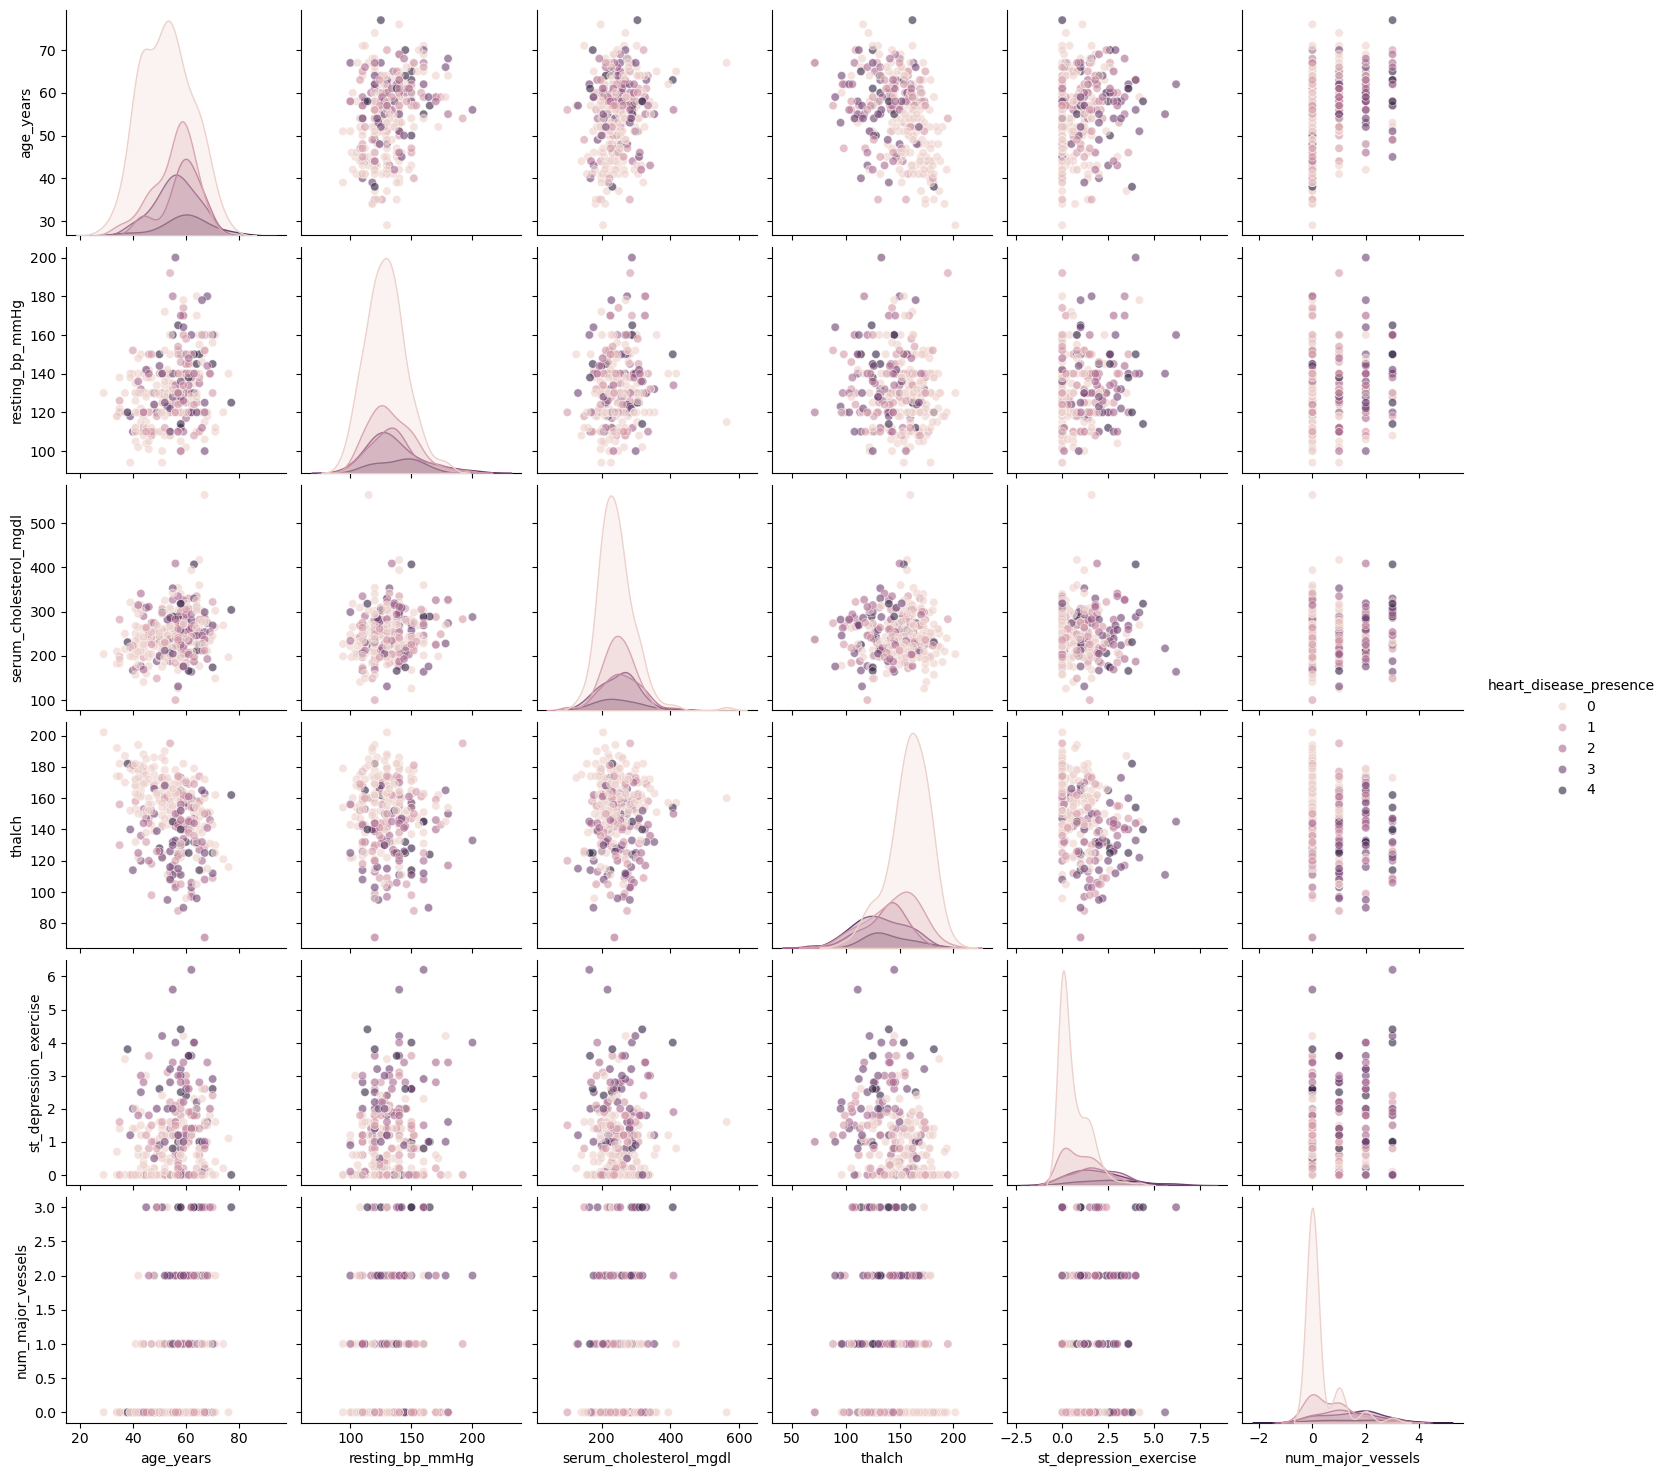

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming my DataFrame is called df

# Select only numeric columns for pairplot
numeric_cols = [
    'age_years',
    'resting_bp_mmHg',
    'serum_cholesterol_mgdl',
    'thalch',
    'st_depression_exercise',
    'num_major_vessels'
]

# Create pairplot, color by target variable
sns.pairplot(df[numeric_cols + ['heart_disease_presence']], 
             hue='heart_disease_presence', 
             diag_kind='kde', 
             plot_kws={'alpha':0.6})

plt.show()


In [44]:
#Outlier Count
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
print(outliers)


age_years                  0
resting_bp_mmHg            9
serum_cholesterol_mgdl     6
thalch                     1
st_depression_exercise     5
num_major_vessels         20
dtype: int64


In [45]:
#Age years has no outliers (Clean Distribution)
#resting_bp_mmHg has 9 Outliers (Moderate Distribution)
#serum_cholesterol_mgdl has 6 Outliers (Moderate Distribution)
#thalch has 1 outlier (Minimal Distribution)
#st_depression_exercise has 5 outliers (Moderate Distribution)
#num_major_vessels has 20 outliers (High Distribution)

<Axes: xlabel='num_major_vessels', ylabel='count'>

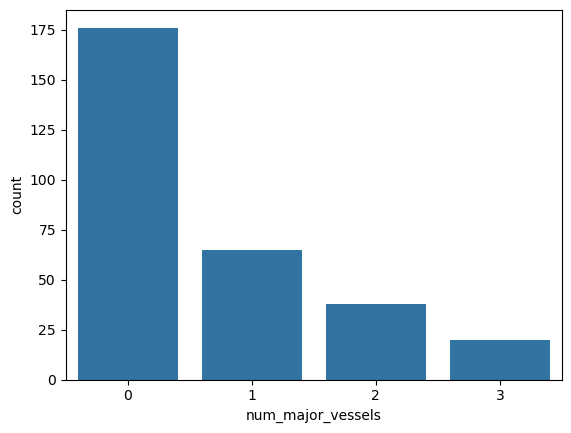

In [46]:
import seaborn as sns
sns.countplot(x='num_major_vessels', data=df)




In [47]:
import numpy as np
import pandas as pd

#Removal of major Outliers in 'num_major_vessels' column

# Step 1: Calculate Q1, Q3, and IQR for the column
Q1 = df['num_major_vessels'].quantile(0.25)
Q3 = df['num_major_vessels'].quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3a: Remove outliers (rows outside bounds)
df_clean = df[(df['num_major_vessels'] >= lower_bound) & (df['num_major_vessels'] <= upper_bound)]

# Step 3b: Cap values at bounds (Winsorization)
df['num_major_vessels'] = np.clip(df['num_major_vessels'], lower_bound, upper_bound)

# Step 3c: Create an outlier flag column (True if outlier, False otherwise)
df['num_major_vessels_outlier'] = ~((df['num_major_vessels'] >= lower_bound) & (df['num_major_vessels'] <= upper_bound))


In [48]:
#Outlier Count
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()
print(outliers)


age_years                 0
resting_bp_mmHg           9
serum_cholesterol_mgdl    6
thalch                    1
st_depression_exercise    5
num_major_vessels         0
dtype: int64


<Axes: xlabel='num_major_vessels', ylabel='count'>

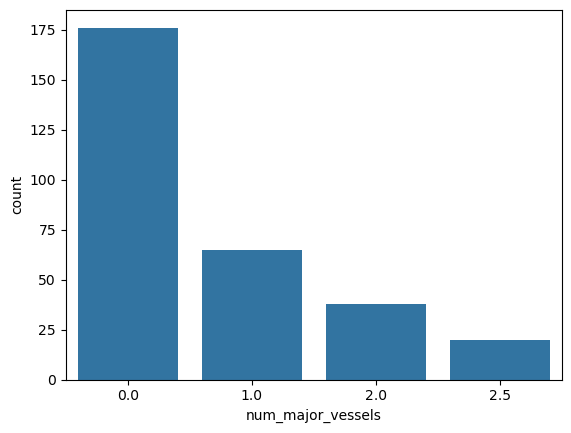

In [49]:
import seaborn as sns
sns.countplot(x='num_major_vessels', data=df)


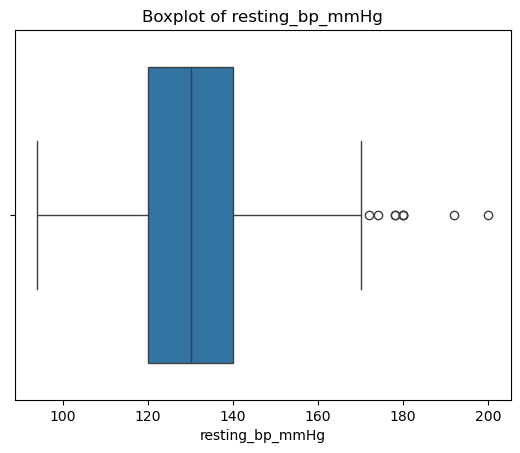

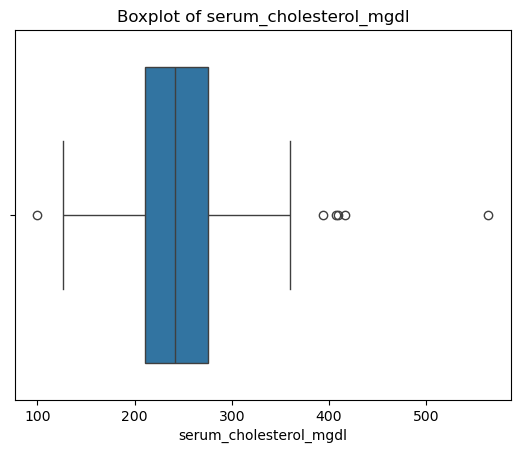

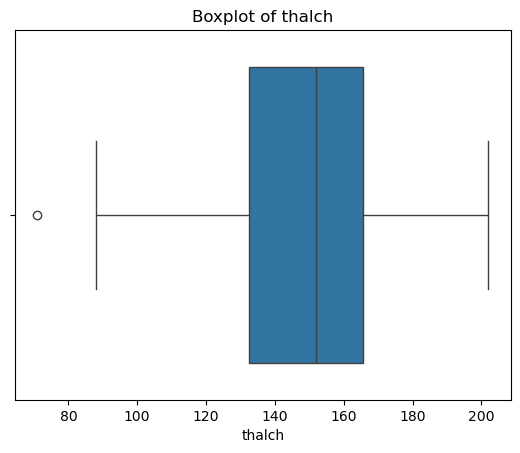

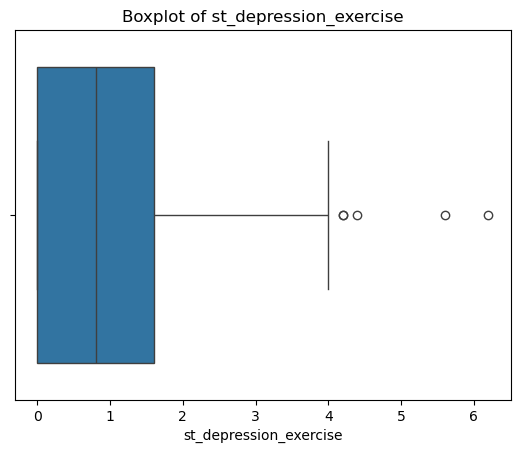

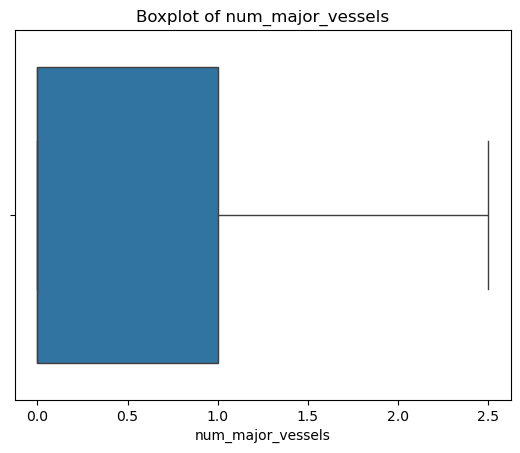

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['resting_bp_mmHg', 'serum_cholesterol_mgdl', 'thalch', 'st_depression_exercise', 'num_major_vessels']:
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
#Defining Splitting of data into X and Y
# Define predictors (X) and target (y)

# We drop columns that should NOT be used as predictors:
# - patient_id: just an identifier, carries no medical meaning
# - dataset: metadata about source, not a clinical feature
# - heart_disease_presence: this is our target, so exclude from predictors
X = df.drop(columns=["patient_id", "dataset", "heart_disease_presence"], errors="ignore")

# Target variable:
# We use heart_disease_presence because it encodes severity numerically (0–4).
# This makes it suitable for classification models.
y = df["heart_disease_presence"]

print("X shape:", X.shape)  # Number of samples × predictors
print("y shape:", y.shape)  # Number of samples × target labels

# Split into train/test sets for modeling
# test_size=0.2 → 20% of data reserved for testing
# random_state=42 → ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=7
)


X shape: (299, 14)
y shape: (299,)


In [52]:
import pandas as pd

# Convert categorical columns into dummy/indicator variables
X_encoded = pd.get_dummies(X, drop_first=True)

# Split again with encoded features
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

#First model: Linear Regression

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [53]:
#Second Model: Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()
dtr.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [ ]:
#Third Model : Gradient Boosting Regressor (wrong model)
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators = 1000, learning_rate = 0.1 , max_depth = 9, min_samples_leaf = 15, max_features = 0.2, loss = 'huber', random_state= 5)
gbr.fit(X_train, y_train)

,loss,'huber'
,learning_rate,0.1
,n_estimators,1000
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_depth,9
,min_impurity_decrease,0.0
,init,None


In [55]:
from sklearn.metrics import mean_absolute_error

# Calculate MAE for Training Set for my Linear Regression model
mae_lr = mean_absolute_error(y_train, lr.predict(X_train))
print("Linear Regression MAE for Training Set: %.4f" % mae_lr)

# Calculate MAE for Test Set for my Linear Regression model
mae_lr = mean_absolute_error(y_test, lr.predict(X_test))
print("Linear Regression MAE for Test Set: %.4f" % mae_lr)



Linear Regression MAE for Training Set: 0.5982
Linear Regression MAE for Test Set: 0.6548


In [56]:
#

In [57]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Constrain the tree to avoid overfitting
dt_reg = DecisionTreeRegressor(
    random_state=42,
    max_depth=5,            # limit depth of the tree
    min_samples_split=10,   # require at least 10 samples to split a node
    min_samples_leaf=5      # require at least 5 samples per leaf
)

dt_reg.fit(X_train, y_train)

# Evaluate again
mae_train = mean_absolute_error(y_train, dt_reg.predict(X_train))
mae_test = mean_absolute_error(y_test, dt_reg.predict(X_test))
# mse_train = mean_squared_error(y_train, dt_reg.predict(X_train))
# mse_test = mean_squared_error(y_test, dt_reg.predict(X_test))

print("Decision Tree Regression MAE (Train): %.4f" % mae_train)
print("Decision Tree Regression MAE (Test): %.4f" % mae_test)
# print("Decision Tree Regression MSE (Train): %.4f" % mse_train)
# print("Decision Tree Regression MSE (Test): %.4f" % mse_test)


Decision Tree Regression MAE (Train): 0.4700
Decision Tree Regression MAE (Test): 0.6603


In [58]:
#

In [59]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Step 1: Create the Gradient Boosting Regression model
gbr = GradientBoostingRegressor(
    random_state=42,
    n_estimators=200,   # number of boosting stages
    learning_rate=0.1,  # step size shrinkage
    max_depth=3         # depth of individual regression estimators
)

# Step 2: Fit the model on my training data
gbr.fit(X_train, y_train)

# Step 3: Evaluate MAE and MSE on training set
mae_train = mean_absolute_error(y_train, gbr.predict(X_train))
# mse_train = mean_squared_error(y_train, gbr.predict(X_train))
mae_test = mean_absolute_error(y_test, gbr.predict(X_test))
# mse_test = mean_squared_error(y_test, gbr.predict(X_test))

print("Gradient Boosting Regression MAE (Train): %.4f" % mae_train)
# print("Gradient Boosting Regression MSE (Train): %.4f" % mse_train)
print("Gradient Boosting Regression MAE (Test): %.4f" % mae_test)
# print("Gradient Boosting Regression MSE (Test): %.4f" % mse_test)


Gradient Boosting Regression MAE (Train): 0.1554
Gradient Boosting Regression MAE (Test): 0.6753


In [60]:
#

In [65]:
import optuna
import numpy as np
from time import time
from sklearn.ensemble import GradientBoostingRegressor   # <-- switched to Gradient Boosting
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Track runtime
start = time()
speed = {}

def objective(trial):
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Auto-detect categorical and numeric columns
    categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
    numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', 'passthrough', numeric_features)
        ]
    )

    # Suggest hyperparameters for Gradient Boosting
    n_estimators = trial.suggest_int("n_estimators", 50, 300)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    max_depth = trial.suggest_int("max_depth", 2, 8)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)

    # Build pipeline
    model = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', GradientBoostingRegressor(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        ))
    ])

    # Train and evaluate
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)

    return mae

# Run Optuna
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=20)

# Record runtime
speed['GradientBoosting'] = np.round(time() - start, 3)

# Print best parameters
print("Best trial:")
trial = study.best_trial
print(f"  MAE: {trial.value}")
print("  Parameters:")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

print(f"Run time: {speed['GradientBoosting']}s")

# Evaluate best model on train/test
best_params = trial.params
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(**best_params, random_state=42))
])

model.fit(X_train, y_train)

# Metrics
mae_train = mean_absolute_error(y_train, model.predict(X_train))
mae_test = mean_absolute_error(y_test, model.predict(X_test))
# mse_train = mean_squared_error(y_train, model.predict(X_train))
# mse_test = mean_squared_error(y_test, model.predict(X_test))

print(f"MAE train: {mae_train:.4f}, MAE test: {mae_test:.4f}")
# print(f"MSE train: {mse_train:.4f}, MSE test: {mse_test:.4f}")


[I 2026-01-18 22:05:31,311] A new study created in memory with name: no-name-b7d0fb65-5a52-494a-b77d-69e6f3e03035
[I 2026-01-18 22:05:31,371] Trial 0 finished with value: 0.6278622658625128 and parameters: {'n_estimators': 58, 'learning_rate': 0.09775191860131811, 'max_depth': 7, 'subsample': 0.7919394275701673, 'min_samples_split': 10, 'min_samples_leaf': 14}. Best is trial 0 with value: 0.6278622658625128.
[I 2026-01-18 22:05:31,414] Trial 1 finished with value: 0.6631106825148975 and parameters: {'n_estimators': 52, 'learning_rate': 0.13604530700757267, 'max_depth': 2, 'subsample': 0.9567493559297555, 'min_samples_split': 20, 'min_samples_leaf': 10}. Best is trial 0 with value: 0.6278622658625128.
[I 2026-01-18 22:05:31,543] Trial 2 finished with value: 0.6848952985427627 and parameters: {'n_estimators': 169, 'learning_rate': 0.09468670226897294, 'max_depth': 3, 'subsample': 0.8480275798122442, 'min_samples_split': 13, 'min_samples_leaf': 7}. Best is trial 0 with value: 0.6278622658

Best trial:
  MAE: 0.5989737104775826
  Parameters:
    n_estimators: 296
    learning_rate: 0.010608243119184525
    max_depth: 5
    subsample: 0.9991789709196321
    min_samples_split: 16
    min_samples_leaf: 12
Run time: 3.528s
MAE train: 0.4069, MAE test: 0.5990


In [ ]:
# - Improved generalization: Test MAE dropped compared to my baseline Gradient Boosting run.
# - Stable performance: Train/Test gap is acceptable, meaning the model isn’t memorizing training data excessively.


In [66]:
import os
import joblib

# Make sure the folder exists
os.makedirs("Models", exist_ok=True)

# Save model to file
joblib.dump(model, "Models/trained_HD_model.pkl")
print("Model saved to   ")


Model saved to   


In [68]:
import numpy as np
import joblib

# Load trained pipeline
model = joblib.load("Models/trained_HD_model.pkl")

# Get feature names after preprocessing
preprocessor = model.named_steps['preprocessor']
feature_labels = preprocessor.get_feature_names_out()

# Extract feature importances from Gradient Boosting
importances = model.named_steps['regressor'].feature_importances_

# Normalize to percentages
percentages = (importances / importances.sum()) * 100

# Sort by importance
sorted_indices = np.argsort(importances)[::-1]

# Print ranked features with percentages
print("Feature Importance Ranking (as % of total importance):")
for idx in sorted_indices:
    print(f"{feature_labels[idx]} - {percentages[idx]:.2f}%")


Feature Importance Ranking (as % of total importance):
num__st_depression_exercise - 20.50%
num__num_major_vessels - 18.67%
cat__chest_pain_type_asymptomatic - 17.46%
cat__thal_defect_type_normal - 13.46%
num__thalch - 7.33%
num__resting_bp_mmHg - 4.34%
num__serum_cholesterol_mgdl - 4.02%
cat__exercise_induced_angina_True - 2.93%
cat__exercise_induced_angina_False - 2.82%
num__age_years - 2.13%
cat__resting_ecg_result_lv hypertrophy - 1.08%
cat__thal_defect_type_reversable defect - 0.98%
cat__resting_ecg_result_normal - 0.96%
cat__st_slope_peak_exercise_flat - 0.85%
cat__sex_male_female_Female - 0.75%
cat__st_slope_peak_exercise_upsloping - 0.60%
cat__sex_male_female_Male - 0.54%
cat__chest_pain_type_non-anginal - 0.44%
cat__chest_pain_type_typical angina - 0.12%
cat__fasting_blood_sugar_gt120_False - 0.01%
cat__chest_pain_type_atypical angina - 0.01%
cat__st_slope_peak_exercise_downsloping - 0.00%
cat__num_major_vessels_outlier_False - 0.00%
cat__resting_ecg_result_st-t abnormality - 

In [ ]:
# #TOP Features Driving Heart Disease Prediction:

# - ST depression during exercise (20.50%)
# - Strongest predictor. Reflects abnormal ECG changes under stress, highly correlated with heart disease risk.

# - Number of major vessels (18.67%)
# - Anatomical measure of blocked vessels. Critical in cardiovascular diagnosis.

# - Chest pain type: asymptomatic (17.46%)
# - Patients with asymptomatic chest pain are at higher risk.

# - Thal defect type: normal (13.46%)
# - Normal thalium scan reduces risk; deviations are predictive.

# - Maximum heart rate achieved (thalch) (7.33%)
# - Exercise capacity and cardiac stress response.
